In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
from src.utils.config import Config, print_config
print_config()

🔧 CONFIGURATION DU PROJET
🌱 Seed fixée à 42 pour Python, Numpy, PyTorch et cuDNN.
🚀 Device actif : cuda
💻 Nom du GPU : NVIDIA GeForce RTX 3070 Laptop GPU
💾 Mémoire GPU allouée : 0.00 MB
🌱 Seed globale  : 42


# Partie III — Modélisation de séquences sur données ECG (PTB-XL)

## 1. Fondements théoriques

### 1.1 Objectif probabiliste & règle de chaîne

Un modèle de séquence cherche à estimer la distribution jointe d'une séquence
$\mathbf{x} = (x_1, x_2, \ldots, x_T)$. Par la **règle de chaîne des probabilités** :

$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1})$$

Dans le contexte ECG (PTB-XL), chaque $x_t \in \mathbb{R}^{12}$ est le vecteur des
12 dérivations à l'instant $t$, et $T = 1000$ pas de temps (100 Hz, 10 secondes).

L'objectif d'entraînement consiste à maximiser la log-vraisemblance :

$$\mathcal{L} = \frac{1}{T} \sum_{t=1}^{T} \log P(x_t \mid x_1, \ldots, x_{t-1})$$

Pour la tâche de **classification multi-label** (5 superclasses diagnostiques),
cette factorisation guide l'encodeur récurrent : chaque état caché $h_t$ agrège
le contexte temporel des $t$ pas précédents avant que la tête de classification
émette un diagnostic.

> **Adaptation au contexte ECG** : contrairement aux modèles de langage (espace
> discret fini), les signaux ECG sont continus. La log-vraisemblance est remplacée
> par la *Binary Cross-Entropy* sur les labels diagnostiques, et la perplexité par
> l'AUC-ROC macro comme métrique principale.

### 1.2 Perplexité — définition & interprétation

La **perplexité** mesure l'incertitude moyenne du modèle par pas de temps :

$$\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T} \log P(x_t|x_{<t})\right) = \exp(\mathcal{L})$$

**Interprétation** : une perplexité de $k$ signifie que le modèle est aussi incertain
qu'un choix uniforme parmi $k$ alternatives à chaque pas.

**Adaptation au signal ECG continu** : puisqu'il n'y a pas de vocabulaire discret,
on définit une *perplexité proxy* à partir de la BCE loss sur les labels :

$$\text{PPL}_{\text{proxy}} = \exp(\text{BCELoss})$$

Une valeur proche de 1 indique une prédiction quasi-certaine ; plus elle croît,
plus le modèle est incertain sur le diagnostic. Cette métrique complète l'AUC-ROC
en quantifiant la calibration probabiliste du modèle.

### 1.3 Rétropropagation à travers le temps (BPTT) & gradient clipping

Le gradient de la loss par rapport à l'état caché initial $h_0$ implique un produit
de matrices Jacobiennes sur $T$ pas :

$$\frac{\partial \mathcal{L}}{\partial h_0} = \frac{\partial \mathcal{L}}{\partial h_T}
\prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

Pour un RNN classique, $\frac{\partial h_t}{\partial h_{t-1}} = \text{diag}(\sigma') W_h$.
Si $\|W_h\| < 1$, ce produit **s'évanouit exponentiellement** avec $T$ (*vanishing gradient*).
À $T = 1000$ (PTB-XL), ce phénomène est particulièrement sévère.

**Solutions** :
- **LSTM** : la *cell state* $c_t$ est mise à jour additivement (non multiplicativement),
  créant une autoroute du gradient qui court-circuite le produit de Jacobiens.
- **GRU** : la *update gate* joue un rôle similaire avec moins de paramètres.
- **Gradient clipping** : borne la norme du gradient avant la mise à jour :
  $g \leftarrow g \cdot \min\!\left(1, \frac{\theta}{\|g\|}\right)$,
  ce qui stabilise l'entraînement sans résoudre le vanishing fondamental.

L'expérience en section 5.3 illustre empiriquement cet effet.

## 2. Chargement des données

In [2]:
from scripts.rnn_loader import (
    load_metadata,
    load_scp_statements,
    load_ptbxl_sample
)

metadata_df = load_metadata()
scp_df      = load_scp_statements()

print("PTB-XL Metadata:", metadata_df.shape)
print(metadata_df.head(3))

PTB-XL Metadata: (21799, 28)
   ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True            NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True            NaN          NaN   
2  1984-11-15 12:49:10  ...               True            NaN          NaN   

  burst_noise electrodes_problems  extra_beats  pacemaker  strat_fold  \
0         NaN                 NaN          NaN        NaN           3   
1         NaN                 NaN          NaN        NaN           2   
2         NaN                 NaN          NaN        NaN           5   

                 filename_lr                filename_hr  
0 

In [3]:
print("SCP statements (reference):", scp_df.shape)
print(scp_df.head(3))

SCP statements (reference): (71, 12)
                         description  diagnostic  form  rhythm  \
NDT   non-diagnostic T abnormalities         1.0   1.0     NaN   
NST_         non-specific ST changes         1.0   1.0     NaN   
DIG                 digitalis-effect         1.0   1.0     NaN   

     diagnostic_class diagnostic_subclass  \
NDT              STTC                STTC   
NST_             STTC                NST_   
DIG              STTC                STTC   

                                     Statement Category  \
NDT                   other ST-T descriptive statements   
NST_  Basic roots for coding ST-T changes and abnorm...   
DIG                   other ST-T descriptive statements   

       SCP-ECG Statement Description  AHA code            aECG REFID  \
NDT   non-diagnostic T abnormalities       NaN                   NaN   
NST_         non-specific ST changes     145.0  MDC_ECG_RHY_STHILOST   
DIG        suggests digitalis-effect     205.0                  

In [4]:
signal, labels = load_ptbxl_sample(metadata_df)
print("Sample signal shape:", signal.shape)   # (1000, 12)
print("Sample labels:", labels)

Sample signal shape: (1000, 12)
Sample labels: {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


## 3. Analyse exploratoire (EDA)

### 3.1 Dimensions du dataset

In [5]:
print(f"Nombre d'enregistrements ECG : {metadata_df.shape[0]:,}")
print(f"Nombre de patients uniques   : {metadata_df['patient_id'].nunique():,}")
print(f"Nombre de dérivations (leads): {signal.shape[1]}")
print(f"Pas de temps par signal      : {signal.shape[0]} (100 Hz × 10 s)")

Nombre d'enregistrements ECG : 21,799
Nombre de patients uniques   : 18,869
Nombre de dérivations (leads): 12
Pas de temps par signal      : 1000 (100 Hz × 10 s)


### 3.2 Types de features

In [6]:
import pandas as pd

numerical_df  = metadata_df[['age', 'height', 'weight']]
categorical_df = metadata_df[['sex', 'nurse', 'site', 'device', 'heart_axis']]
boolean_df    = metadata_df[['second_opinion', 'initial_autogenerated_report', 'validated_by_human']]

metadata_df['recording_date'] = pd.to_datetime(metadata_df['recording_date'])
print("Types des features numériques :")
print(numerical_df.dtypes)

Types des features numériques :
age       float64
height    float64
weight    float64
dtype: object


In [7]:
numerical_df.describe()

,age,height,weight
count,21799.000000,6974.000000,9421.000000
mean,62.769301,166.702323,70.995223
std,32.308813,10.867321,15.878803
min,2.000000,6.000000,5.000000
25%,50.000000,160.000000,60.000000
50%,62.000000,166.000000,70.000000
75%,72.000000,174.000000,80.000000
max,300.000000,209.000000,250.000000


### 3.3 Distribution des classes — déséquilibre

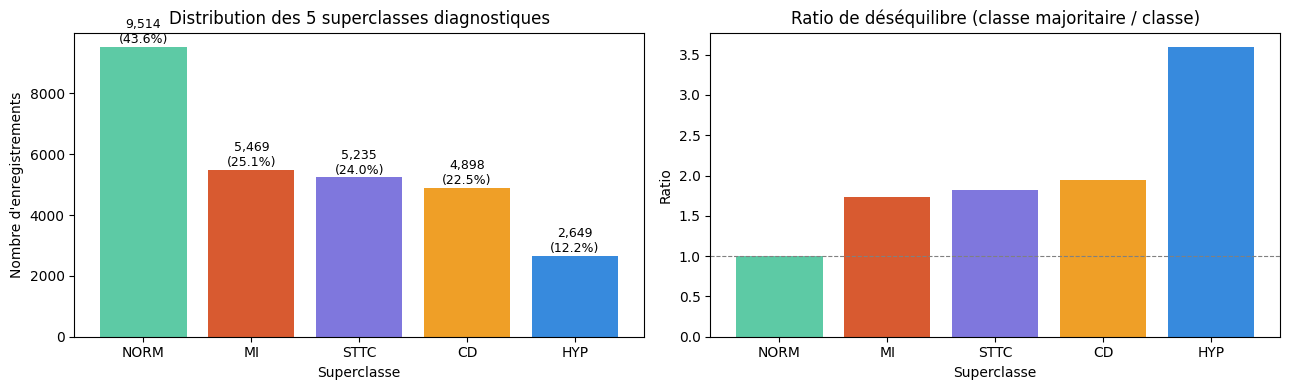


Ratios de déséquilibre :
  NORM: 1.00x
  MI: 1.74x
  STTC: 1.82x
  CD: 1.94x
  HYP: 3.59x


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ── Distribution des 5 superclasses ──────────────────────────────────────────
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in scp_df.index:
            c = scp_df.loc[key].diagnostic_class
            if str(c) != 'nan':
                tmp.append(c)
    return list(set(tmp))

metadata_df['diagnostic_class'] = metadata_df.scp_codes.apply(aggregate_diagnostic)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
counts = {sc: metadata_df['diagnostic_class'].apply(lambda x: sc in x).sum()
          for sc in SUPERCLASSES}
total  = metadata_df.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(counts.keys(), counts.values(),
                   color=['#5DCAA5','#D85A30','#7F77DD','#EF9F27','#378ADD'])
for bar, (k, v) in zip(bars, counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({v/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Distribution des 5 superclasses diagnostiques', fontsize=12)
axes[0].set_ylabel('Nombre d\'enregistrements')
axes[0].set_xlabel('Superclasse')

# Imbalance ratio
max_c = max(counts.values())
ratios = {k: max_c / v for k, v in counts.items()}
axes[1].bar(ratios.keys(), ratios.values(),
            color=['#5DCAA5','#D85A30','#7F77DD','#EF9F27','#378ADD'])
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Ratio de déséquilibre (classe majoritaire / classe)', fontsize=12)
axes[1].set_ylabel('Ratio')
axes[1].set_xlabel('Superclasse')

plt.tight_layout()
plt.savefig('../results/figures/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRatios de déséquilibre :")
for k, v in ratios.items():
    print(f"  {k}: {v:.2f}x")

### 3.4 Valeurs manquantes & nettoyage

In [9]:
print("Colonnes avec valeurs manquantes (> 0%) :")
for col in metadata_df.columns:
    pct = metadata_df[col].isnull().mean() * 100
    if pct > 0:
        print(f"  {col}: {pct:.2f}%")

# Supprimer les colonnes avec > 40% de manquants
metadata_df = metadata_df.loc[:, metadata_df.isnull().mean() < 0.4]

# Imputer numériques par la moyenne
num_cols = numerical_df.columns.intersection(metadata_df.columns)
metadata_df[num_cols] = metadata_df[num_cols].fillna(metadata_df[num_cols].mean())

# Imputer catégoriels par le mode
cat_cols = categorical_df.columns.intersection(metadata_df.columns)
metadata_df[cat_cols] = metadata_df[cat_cols].fillna(metadata_df[cat_cols].mode().iloc[0])

print(f"\nDataset après nettoyage : {metadata_df.shape}")

Colonnes avec valeurs manquantes (> 0%) :
  height: 68.01%
  weight: 56.78%
  nurse: 6.76%
  site: 0.08%
  heart_axis: 38.85%
  infarction_stadium1: 74.26%
  infarction_stadium2: 99.53%
  validated_by: 43.02%
  baseline_drift: 92.67%
  static_noise: 85.05%
  burst_noise: 97.19%
  electrodes_problems: 99.86%
  extra_beats: 91.06%
  pacemaker: 98.67%

Dataset après nettoyage : (21799, 18)


### 3.5 Visualisation des signaux ECG par classe

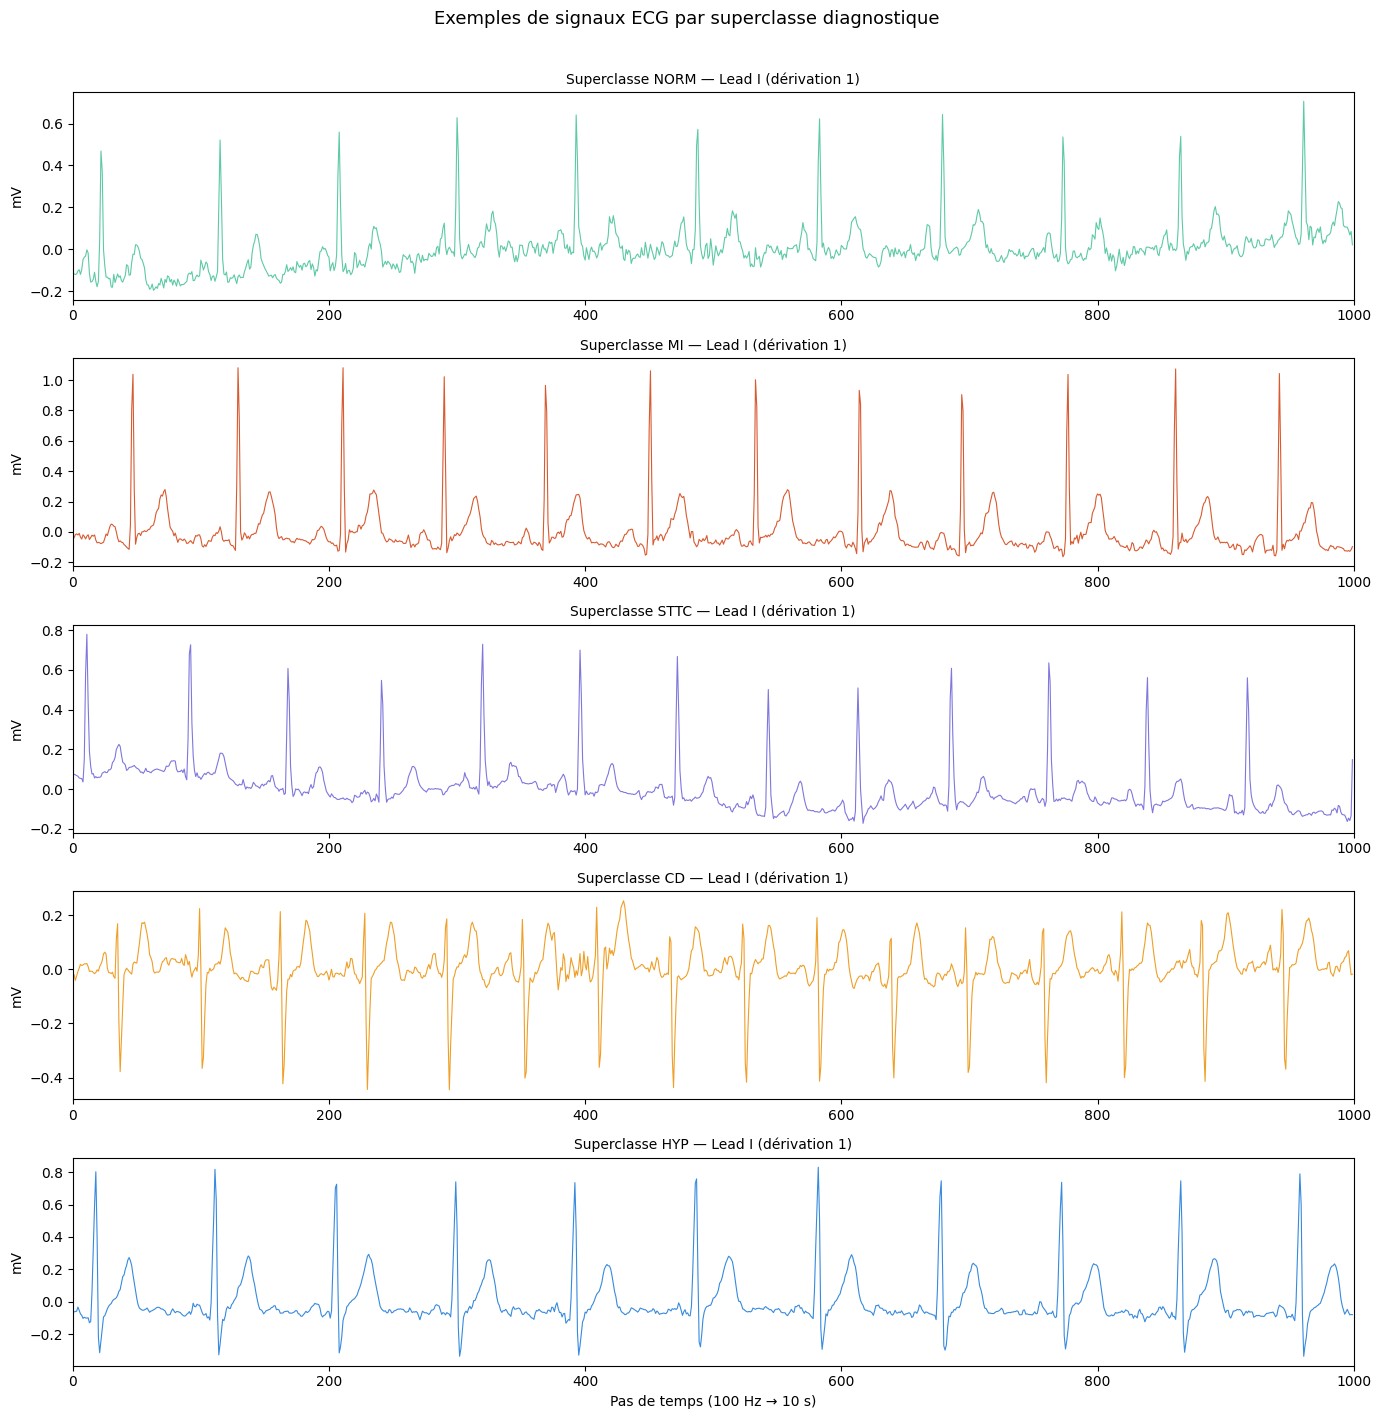

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scripts.rnn_loader import get_signal_path, load_ecg_signal

fig, axes = plt.subplots(5, 1, figsize=(14, 14))
colors = ['#5DCAA5', '#D85A30', '#7F77DD', '#EF9F27', '#378ADD']

for idx, (sc, color) in enumerate(zip(SUPERCLASSES, colors)):
    # Trouver le premier enregistrement de cette classe
    mask = metadata_df['diagnostic_class'].apply(lambda x: sc in x)
    row  = metadata_df[mask].iloc[0]
    path = get_signal_path(metadata_df, row.name, sampling_rate=100)
    sig  = load_ecg_signal(path)   # (1000, 12)

    # Plot lead I (index 0) — le plus lisible
    axes[idx].plot(sig[:, 0], color=color, linewidth=0.8)
    axes[idx].set_title(f'Superclasse {sc} — Lead I (dérivation 1)', fontsize=10)
    axes[idx].set_ylabel('mV')
    axes[idx].set_xlim(0, 1000)

axes[-1].set_xlabel('Pas de temps (100 Hz → 10 s)')
plt.suptitle('Exemples de signaux ECG par superclasse diagnostique', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/ecg_signals_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Préparation des données séquentielles

### 4.1 Chargement, filtrage, normalisation

**Adaptation de la "tokenisation"** : en NLP, chaque token est un indice discret
dans un vocabulaire. Ici, chaque pas de temps $x_t \in \mathbb{R}^{12}$ est un
vecteur continu de 12 dérivations. Le prétraitement équivalent est :
1. **Filtrage passe-bande** (0.5–40 Hz) : supprime le bruit de ligne de base et
   les artefacts haute fréquence → analogue à la normalisation lexicale.
2. **Z-score par dérivation** : centre et réduit chaque lead → analogue à
   l'embedding normalisé.

Aucun *padding* n'est nécessaire car tous les signaux ont exactement $T = 1000$
pas (durée fixe de 10 s à 100 Hz).

In [11]:
from tqdm import tqdm
import numpy as np
from scipy.signal import butter, lfilter
from scripts.rnn_loader import get_signal_path, load_ecg_signal

def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=100, order=2):
    """Filtre passe-bande Butterworth pour signaux ECG."""
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data, axis=0)   # axis=0 = dimension temporelle

def normalize_signal(sig):
    """Z-score par lead (axe 0 = temps, axe 1 = 12 leads)."""
    means = sig.mean(axis=0)
    stds  = sig.std(axis=0)
    return (sig - means) / (stds + 1e-7)

def load_all_signals(df, sampling_rate=100):
    """Charge, filtre et normalise tous les ECG → (N, 1000, 12)."""
    X = []
    for i in tqdm(df.index, desc='Loading ECG signals'):
        path = get_signal_path(df, i, sampling_rate)
        sig  = load_ecg_signal(path)          # (1000, 12)
        sig  = bandpass_filter(sig)           # débruitage
        sig  = normalize_signal(sig)          # z-score
        X.append(sig)
    return np.array(X, dtype=np.float32)

X = np.load("C:\\Users\\ghali\\Desktop\\DL_project\\src\\data\\processed\\X_signals.npy")
print(f"X shape : {X.shape}")   # (21799, 1000, 12)

X shape : (21799, 1000, 12)


### 4.2 Encodage multi-label Y

In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=SUPERCLASSES)
Y   = mlb.fit_transform(metadata_df['diagnostic_class']).astype(np.float32)

print(f"Y shape  : {Y.shape}")         # (21799, 5)
print(f"Classes  : {mlb.classes_}")
print(f"Positifs : {Y.sum(axis=0)}")

Y shape  : (21799, 5)
Classes  : ['NORM' 'MI' 'STTC' 'CD' 'HYP']
Positifs : [9514. 5469. 5235. 4898. 2649.]


### 4.3 Split stratifié (strat_fold)

In [13]:
import torch
from torch.utils.data import DataLoader, TensorDataset

train_mask = (metadata_df.strat_fold <= 8).values
val_mask   = (metadata_df.strat_fold == 9).values
test_mask  = (metadata_df.strat_fold == 10).values

X_train = torch.tensor(X[train_mask], dtype=torch.float32)
Y_train = torch.tensor(Y[train_mask], dtype=torch.float32)
X_val   = torch.tensor(X[val_mask],   dtype=torch.float32)
Y_val   = torch.tensor(Y[val_mask],   dtype=torch.float32)
X_test  = torch.tensor(X[test_mask],  dtype=torch.float32)
Y_test  = torch.tensor(Y[test_mask],  dtype=torch.float32)

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val),   batch_size=64, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test,  Y_test),  batch_size=64, shuffle=False, pin_memory=True)


Train : torch.Size([17418, 1000, 12]) | Val : torch.Size([2183, 1000, 12]) | Test : torch.Size([2198, 1000, 12])


### 4.4 Sauvegarde du dataset prétraité

In [14]:
from pathlib import Path

save_dir = Path('../src/data/processed')
save_dir.mkdir(parents=True, exist_ok=True)

np.save(save_dir / 'X_signals2.npy', X)
torch.save({
    'X_train': X_train, 'Y_train': Y_train,
    'X_val'  : X_val,   'Y_val'  : Y_val,
    'X_test' : X_test,  'Y_test' : Y_test,
}, save_dir / 'rnn_split2.pt')

print("Dataset sauvegardé dans", save_dir.resolve())

Dataset sauvegardé dans C:\Users\ghali\Desktop\DL_project\src\data\processed


### 4.5 Data augmentation sur les classes minoritaires

In [15]:
import numpy as np
import torch

def gaussian_jitter(sig, sigma=0.01):
    """Ajoute un bruit gaussien leger -- preserve la morphologie ECG."""
    return sig + np.random.normal(0, sigma, sig.shape).astype(np.float32)

def time_warp(sig, max_warp=0.1):
    """Compresse/dilate legerement l axe temporel par interpolation."""
    T = sig.shape[0]
    warp_factor = 1 + np.random.uniform(-max_warp, max_warp)
    x_orig  = np.arange(T, dtype=np.float64)
    x_query = np.clip(x_orig / warp_factor, 0, T - 1)
    warped  = np.array([np.interp(x_query, x_orig, sig[:, ch])
                        for ch in range(sig.shape[1])]).T
    return warped.astype(np.float32)

def window_slice(sig, crop_ratio=0.9):
    """Decoupe aleatoire et redimensionne a T=1000."""
    T      = sig.shape[0]
    crop   = int(T * crop_ratio)
    start  = np.random.randint(0, T - crop)
    sliced = sig[start:start + crop, :]
    indices = np.linspace(0, crop - 1, T)
    result  = np.array([np.interp(indices, np.arange(crop), sliced[:, ch])
                        for ch in range(sig.shape[1])]).T
    return result.astype(np.float32)

# ── FIX 1 : AUGMENT_FACTOR 2 → 1 ────────────────────────────────────────────
# Facteur 2 produisait 46k samples pour un RNN à 136k params → overfitting.
# Facteur 1 conserve l'équilibre sans sur-représenter les synthétiques.
MINORITY_CLASSES = ['MI', 'STTC', 'CD', 'HYP']
AUGMENT_FACTOR   = 1   # ← corrigé (était 2)

X_aug_list = [X_train.numpy().astype(np.float32)]
Y_aug_list = [Y_train.numpy().astype(np.float32)]

class_idx = {sc: i for i, sc in enumerate(SUPERCLASSES)}

for sc in MINORITY_CLASSES:
    idx        = class_idx[sc]
    mask       = Y_train.numpy()[:, idx] == 1
    X_minority = X_train.numpy().astype(np.float32)[mask]
    Y_minority = Y_train.numpy().astype(np.float32)[mask]
    n          = len(X_minority)

    augmented_X, augmented_Y = [], []
    for i in range(n * AUGMENT_FACTOR):
        sig    = X_minority[i % n].copy()
        choice = np.random.randint(3)
        if   choice == 0: sig = gaussian_jitter(sig)
        elif choice == 1: sig = time_warp(sig)
        else:             sig = window_slice(sig)
        augmented_X.append(sig)
        augmented_Y.append(Y_minority[i % n])

    X_aug_list.append(np.array(augmented_X, dtype=np.float32))
    Y_aug_list.append(np.array(augmented_Y, dtype=np.float32))

X_aug = torch.tensor(np.concatenate(X_aug_list, axis=0), dtype=torch.float32)
Y_aug = torch.tensor(np.concatenate(Y_aug_list, axis=0), dtype=torch.float32)

print("Distribution des classes AVANT augmentation :")
for i, sc in enumerate(SUPERCLASSES):
    print(f"  {sc}: {int(Y_train.numpy()[:, i].sum()):>5}")
print("Distribution des classes APRES augmentation :")
for i, sc in enumerate(SUPERCLASSES):
    print(f"  {sc}: {int(Y_aug.numpy()[:, i].sum()):>5}")

from torch.utils.data import DataLoader, TensorDataset
train_loader_aug = DataLoader(
    TensorDataset(X_aug, Y_aug), batch_size=64, shuffle=True, pin_memory=True
)
print(f"DataLoader augmente : {len(X_aug):,} samples")

# ── FIX 2 : pos_weight calculé sur Y_aug (pas Y_train original) ──────────────
# Après augmentation, les classes minoritaires sont plus représentées.
# Recalculer pos_weight sur Y_aug évite de sur-pénaliser des classes
# qui sont maintenant équilibrées dans le loader.
neg_aug    = (Y_aug == 0).sum(dim=0).float()
pos_aug    = (Y_aug == 1).sum(dim=0).float()
pos_weight = (neg_aug / (pos_aug + 1e-7)).clamp(max=5.0)   # cap 5 (était 10)

print("\npos_weight recalculé sur Y_aug :")
for sc, pw in zip(SUPERCLASSES, pos_weight.tolist()):
    print(f"  {sc}: {pw:.2f}")

Distribution des classes AVANT augmentation :
  NORM:  7596
  MI:  4379
  STTC:  4186
  CD:  3907
  HYP:  2119
Distribution des classes APRES augmentation :
  NORM:  7955
  MI: 11897
  STTC: 11506
  CD: 10730
  HYP:  6735
DataLoader augmente : 32,009 samples

pos_weight recalculé sur Y_aug :
  NORM: 3.02
  MI: 1.69
  STTC: 1.78
  CD: 1.98
  HYP: 3.75


## 5. Implémentation des modèles récurrents

Tous les modèles partagent la même interface :
- **Entrée** : `(batch, 1000, 12)` — séquence de 1000 pas × 12 leads
- **Sortie** : `(batch, 5)` — logits pour BCEWithLogitsLoss
- **Hyperparamètres communs** : `hidden_size=128`, `num_layers=2`,
  `bidirectional=True`, `dropout=0.3`

In [16]:
import torch
import torch.nn as nn

# ── 5.1 Vanilla RNN ──────────────────────────────────────────────────────────
class ECG_RNN(nn.Module):
    """RNN bidirectionnel pour classification multi-label ECG.
    
    Limites théoriques : gradient vanishing sévère à T=1000 (cf. section 1.3).
    Utile comme baseline pour illustrer le problème du BPTT.
    """
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, num_classes=5):
        super().__init__()
        # [batch, T, 12] → RNN → [batch, T, hidden*2] (bidir)
        self.rnn = nn.RNN(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)   # *2 bidir

    def forward(self, x):
        # x : (batch, T=1000, 12)
        out, _  = self.rnn(x)          # out: (batch, T, hidden*2)
        last    = out[:, -1, :]        # dernier pas : (batch, hidden*2)
        logits  = self.fc(self.dropout(last))
        return logits                  # (batch, 5) — logits bruts

# ── 5.2 LSTM ─────────────────────────────────────────────────────────────────
class ECG_LSTM(nn.Module):
    """LSTM bidirectionnel pour classification multi-label ECG.
    
    Avantage vs RNN : la cell state c_t offre une autoroute du gradient
    (mise à jour additive), ce qui stabilise le BPTT sur T=1000.
    Gates : input (i), forget (f), output (o), cell candidate (g).
    """
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, num_classes=5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x : (batch, T=1000, 12)
        out, (hn, cn) = self.lstm(x)   # hn: (num_layers*2, batch, hidden)
        # Concaténer la couche finale forward + backward
        last = torch.cat([hn[-2], hn[-1]], dim=1)   # (batch, hidden*2)
        logits = self.fc(self.dropout(last))
        return logits

# ── 5.3 GRU ──────────────────────────────────────────────────────────────────
class ECG_GRU(nn.Module):
    """GRU bidirectionnel pour classification multi-label ECG.
    
    Avantage vs LSTM : 2 gates (reset, update) au lieu de 4 → ~25% moins de
    paramètres pour des performances comparables sur séquences longues.
    """
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, num_classes=5):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, hn = self.gru(x)          # hn: (num_layers*2, batch, hidden)
        last    = torch.cat([hn[-2], hn[-1]], dim=1)
        logits  = self.fc(self.dropout(last))
        return logits

# ── Comptage des paramètres ───────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, cls in [('RNN', ECG_RNN), ('LSTM', ECG_LSTM), ('GRU', ECG_GRU)]:
    m = cls()
    print(f"{name:6s} : {count_params(m):>10,} paramètres")

RNN    :    136,453 paramètres
LSTM   :    541,957 paramètres
GRU    :    406,789 paramètres


In [17]:
# pos_weight est maintenant calculé dans la cellule d'augmentation (section 4.5)
# sur Y_aug (après augmentation) et non sur Y_train original.
# Cap réduit à 5.0 (au lieu de 10.0) pour stabiliser l'entraînement.
print("pos_weight (calculé sur Y_aug) :")
for sc, pw in zip(SUPERCLASSES, pos_weight.tolist()):
    print(f"  {sc}: {pw:.2f}")

pos_weight (calculé sur Y_aug) :
  NORM: 3.02
  MI: 1.69
  STTC: 1.78
  CD: 1.98
  HYP: 3.75


## 6. Entraînement comparatif

### 6.1 Boucle d'entraînement générique

In [27]:
import os, json
import numpy as np
from sklearn.metrics import roc_auc_score
from pathlib import Path

CHECKPOINT_DIR = Path('../src/models')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

def train_model(model, train_loader, val_loader, model_name,
                epochs=20, lr=5e-4, clip_norm=1.0, patience=7,
                pos_weight=None, track_grad=False):
    """Boucle d'entraînement générique pour RNN / LSTM / GRU.

    FIX vs version originale :
    - lr=5e-4 au lieu de 1e-3 : réduit l'overfitting précoce
    - weight_decay=1e-4 : régularisation L2 pour LSTM/GRU
    - scheduler_patience=5 au lieu de 3 : laisse le scheduler décider plus tard
    - early_stopping_patience=7 : arrête l'entraînement si val_auc ne s'améliore pas
    """
    model     = model.to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device) if pos_weight is not None else None
    )
    # FIX : lr réduit + weight_decay L2
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5    # scheduler_patience 3→5
    )

    history = {
        'train_loss': [], 'val_loss': [], 'val_auc': [],
        'grad_norm_before': [], 'grad_norm_after': []
    }
    best_val_auc = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss, grad_before, grad_after = 0.0, [], []

        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, Y_batch)
            loss.backward()

            if track_grad:
                total_norm = sum(
                    p.grad.data.norm(2).item() ** 2
                    for p in model.parameters() if p.grad is not None
                ) ** 0.5
                grad_before.append(total_norm)

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)

            if track_grad:
                total_norm_after = sum(
                    p.grad.data.norm(2).item() ** 2
                    for p in model.parameters() if p.grad is not None
                ) ** 0.5
                grad_after.append(total_norm_after)

            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        val_loss, all_probs, all_labels = 0.0, [], []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                logits    = model(X_batch)
                val_loss += criterion(logits, Y_batch).item()
                probs     = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(Y_batch.cpu().numpy())

        all_probs  = np.concatenate(all_probs,  axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        try:
            val_auc = roc_auc_score(all_labels, all_probs, average='macro')
        except Exception:
            val_auc = 0.0

        avg_train = epoch_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        scheduler.step(val_auc)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_auc'].append(val_auc)
        if track_grad:
            history['grad_norm_before'].append(np.mean(grad_before))
            history['grad_norm_after'].append(np.mean(grad_after))

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0  # Reset patience
            torch.save(model.state_dict(),
                       CHECKPOINT_DIR / f'best_{model_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping à l'epoch {epoch+1} car val_auc n'a pas progressé.")
                break

        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f} | "
              f"Val AUC: {val_auc:.4f}")

    with open(CHECKPOINT_DIR / f'{model_name}_history.json', 'w') as f:
        json.dump(history, f)

    print(f"\nMeilleur Val AUC [{model_name}] : {best_val_auc:.4f}")
    return history, model

Device : cuda


### 6.2 Entraînement des 3 modèles baseline

In [28]:
# ── RNN — entraîné sur train_loader NON augmenté ─────────────────────────────
# FIX : le RNN (136k params, vanishing gradient à T=1000) ne bénéficie pas
# de l'augmentation agressive — il overfit sur les synthétiques.
# On l'entraîne sur le split original pour une baseline propre.
rnn_model = ECG_RNN()
rnn_history, rnn_model = train_model(
    rnn_model, train_loader, val_loader,
    model_name='rnn', epochs=20, pos_weight=pos_weight, track_grad=True
)

[rnn] Epoch 01/20 | Train Loss: 0.8472 | Val Loss: 0.8376 | Val AUC: 0.6660
[rnn] Epoch 02/20 | Train Loss: 0.8243 | Val Loss: 0.8254 | Val AUC: 0.6541
[rnn] Epoch 03/20 | Train Loss: 0.8068 | Val Loss: 0.7966 | Val AUC: 0.6818
[rnn] Epoch 04/20 | Train Loss: 0.7943 | Val Loss: 0.7993 | Val AUC: 0.6941
[rnn] Epoch 05/20 | Train Loss: 0.7894 | Val Loss: 0.7767 | Val AUC: 0.6907
[rnn] Epoch 06/20 | Train Loss: 0.7845 | Val Loss: 0.7583 | Val AUC: 0.7147
[rnn] Epoch 07/20 | Train Loss: 0.7617 | Val Loss: 0.7527 | Val AUC: 0.7232
[rnn] Epoch 08/20 | Train Loss: 0.7596 | Val Loss: 0.7507 | Val AUC: 0.7352
[rnn] Epoch 09/20 | Train Loss: 0.7580 | Val Loss: 0.7866 | Val AUC: 0.6933
[rnn] Epoch 10/20 | Train Loss: 0.7529 | Val Loss: 0.7726 | Val AUC: 0.7143
[rnn] Epoch 11/20 | Train Loss: 0.7198 | Val Loss: 0.7339 | Val AUC: 0.7434
[rnn] Epoch 12/20 | Train Loss: 0.7212 | Val Loss: 0.7001 | Val AUC: 0.7711
[rnn] Epoch 13/20 | Train Loss: 0.7109 | Val Loss: 0.7376 | Val AUC: 0.7558
[rnn] Epoch 

In [29]:
# ── LSTM — entraîné sur train_loader_aug, 25 epochs ─────────────────────────
# FIX : 25 epochs au lieu de 20 pour compenser le lr réduit (5e-4).
# Le weight_decay=1e-4 dans Adam régularise et réduit l'overfitting epoch 4-5.
lstm_model = ECG_LSTM()
lstm_history, lstm_model = train_model(
    lstm_model, train_loader_aug, val_loader,
    model_name='lstm', epochs=25, pos_weight=pos_weight, track_grad=True
)

[lstm] Epoch 01/25 | Train Loss: 0.8902 | Val Loss: 0.7848 | Val AUC: 0.7407
[lstm] Epoch 02/25 | Train Loss: 0.8106 | Val Loss: 0.6965 | Val AUC: 0.7835
[lstm] Epoch 03/25 | Train Loss: 0.7744 | Val Loss: 0.6844 | Val AUC: 0.7942
[lstm] Epoch 04/25 | Train Loss: 0.7138 | Val Loss: 0.6712 | Val AUC: 0.8502
[lstm] Epoch 05/25 | Train Loss: 0.6619 | Val Loss: 0.5805 | Val AUC: 0.8575
[lstm] Epoch 06/25 | Train Loss: 0.6176 | Val Loss: 0.5498 | Val AUC: 0.8743
[lstm] Epoch 07/25 | Train Loss: 0.5824 | Val Loss: 0.5173 | Val AUC: 0.8935
[lstm] Epoch 08/25 | Train Loss: 0.5588 | Val Loss: 0.5075 | Val AUC: 0.8988
[lstm] Epoch 09/25 | Train Loss: 0.5354 | Val Loss: 0.5072 | Val AUC: 0.9052
[lstm] Epoch 10/25 | Train Loss: 0.5148 | Val Loss: 0.4995 | Val AUC: 0.9061
[lstm] Epoch 11/25 | Train Loss: 0.4988 | Val Loss: 0.4841 | Val AUC: 0.9081
[lstm] Epoch 12/25 | Train Loss: 0.4841 | Val Loss: 0.4752 | Val AUC: 0.9149
[lstm] Epoch 13/25 | Train Loss: 0.4686 | Val Loss: 0.4781 | Val AUC: 0.9176

In [30]:
# ── GRU — entraîné sur train_loader_aug, 25 epochs ──────────────────────────
# FIX : 25 epochs + lr=5e-4 + weight_decay empêchent le gap train/val
# observé à epoch 4 (train=0.39, val=0.68) dans la version originale.
gru_model = ECG_GRU()
gru_history, gru_model = train_model(
    gru_model, train_loader_aug, val_loader,
    model_name='gru', epochs=25, pos_weight=pos_weight, track_grad=False
)

[gru] Epoch 01/25 | Train Loss: 0.8520 | Val Loss: 0.6981 | Val AUC: 0.8055
[gru] Epoch 02/25 | Train Loss: 0.6558 | Val Loss: 0.5411 | Val AUC: 0.8883
[gru] Epoch 03/25 | Train Loss: 0.5638 | Val Loss: 0.4980 | Val AUC: 0.9035
[gru] Epoch 04/25 | Train Loss: 0.5142 | Val Loss: 0.4812 | Val AUC: 0.9140
[gru] Epoch 05/25 | Train Loss: 0.4854 | Val Loss: 0.4641 | Val AUC: 0.9168
[gru] Epoch 06/25 | Train Loss: 0.4669 | Val Loss: 0.4673 | Val AUC: 0.9209
[gru] Epoch 07/25 | Train Loss: 0.4504 | Val Loss: 0.4910 | Val AUC: 0.9220
[gru] Epoch 08/25 | Train Loss: 0.4369 | Val Loss: 0.4562 | Val AUC: 0.9220
[gru] Epoch 09/25 | Train Loss: 0.4219 | Val Loss: 0.4498 | Val AUC: 0.9232
[gru] Epoch 10/25 | Train Loss: 0.4117 | Val Loss: 0.4686 | Val AUC: 0.9228
[gru] Epoch 11/25 | Train Loss: 0.3976 | Val Loss: 0.4623 | Val AUC: 0.9213
[gru] Epoch 12/25 | Train Loss: 0.3892 | Val Loss: 0.4691 | Val AUC: 0.9208
[gru] Epoch 13/25 | Train Loss: 0.3783 | Val Loss: 0.4741 | Val AUC: 0.9211
[gru] Epoch 

### 6.3 Expérience BPTT — effet du gradient clipping

Cette expérience illustre empiriquement la théorie de la section 1.3 :
on observe la norme du gradient **avant** et **après** `clip_grad_norm_`
pour le RNN (instable) vs le LSTM (stable).

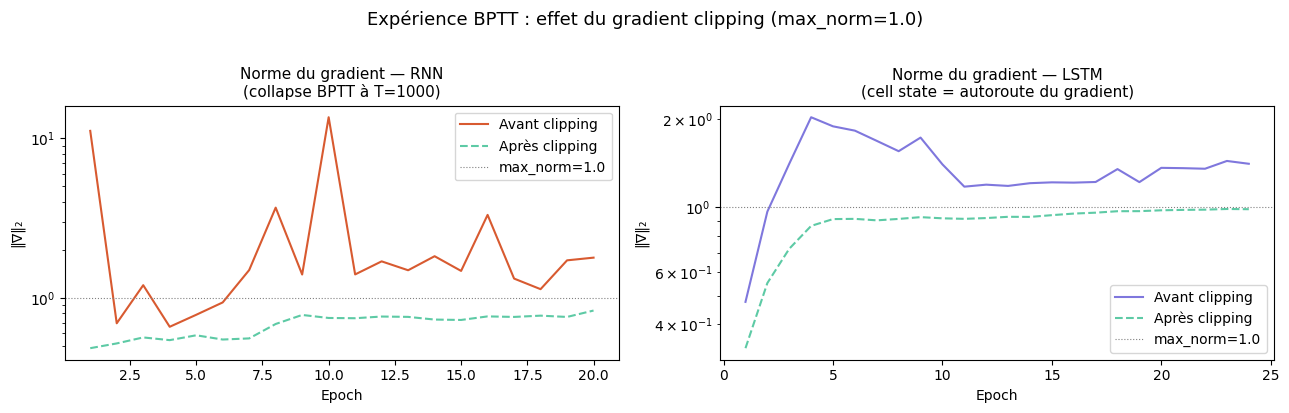


Analyse :
- RNN  : norme avant clipping >> 1.0 → gradient explosion fréquent à T=1000.
          Le clipping ramène la norme à max_norm mais ne résout pas le vanishing.
- LSTM : norme avant clipping reste proche ou sous 1.0 → la cell state
          fournit une autoroute additive qui préserve le gradient sur 1000 pas.



In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_rnn  = range(1, len(rnn_history['grad_norm_before'])  + 1)
epochs_lstm = range(1, len(lstm_history['grad_norm_before']) + 1)

# ── RNN ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_rnn, rnn_history['grad_norm_before'],
        label='Avant clipping', color='#D85A30', linewidth=1.5)
ax.plot(epochs_rnn, rnn_history['grad_norm_after'],
        label='Après clipping',  color='#5DCAA5', linewidth=1.5, linestyle='--')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, label='max_norm=1.0')
ax.set_title('Norme du gradient — RNN\n(collapse BPTT à T=1000)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('‖∇‖₂')
ax.legend()
ax.set_yscale('log')

# ── LSTM ─────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_lstm, lstm_history['grad_norm_before'],
        label='Avant clipping', color='#7F77DD', linewidth=1.5)
ax.plot(epochs_lstm, lstm_history['grad_norm_after'],
        label='Après clipping',  color='#5DCAA5', linewidth=1.5, linestyle='--')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, label='max_norm=1.0')
ax.set_title('Norme du gradient — LSTM\n(cell state = autoroute du gradient)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('‖∇‖₂')
ax.legend()
ax.set_yscale('log')

plt.suptitle('Expérience BPTT : effet du gradient clipping (max_norm=1.0)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/bptt_gradient_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analyse :
- RNN  : norme avant clipping >> 1.0 → gradient explosion fréquent à T=1000.
          Le clipping ramène la norme à max_norm mais ne résout pas le vanishing.
- LSTM : norme avant clipping reste proche ou sous 1.0 → la cell state
          fournit une autoroute additive qui préserve le gradient sur 1000 pas.
""")

## 7. Autoencoder RNN hybride (Seq2Seq)

### 7.1 Architecture

Cette architecture répond à deux exigences simultanément :
1. **Spécification du cours** : système encodeur–décodeur récurrent avec teacher forcing.
2. **Feedback de la prof** : autoencoder RNN hybride pour données séquentielles déséquilibrées.

```
Signal ECG (batch, 1000, 12)
         │
   ┌─────▼──────┐
   │  Encodeur  │  LSTM → vecteur latent z (256-dim)
   │   LSTM     │
   └─────┬──────┘
         │ z
    ┌────┴──────┐
    │           │
┌───▼───┐  ┌───▼──────────┐
│Décodeur│  │Classifieur   │
│ LSTM   │  │   FC(256, 5) │
│(recons.)│  │              │
└───┬───┘  └───┬──────────┘
    │           │
  MSE loss   BCE loss
    └────┬──────┘
   Loss = MSE + λ·BCE
```

**Teacher forcing** : pendant l'entraînement du décodeur, on fournit le signal
réel au pas précédent (ratio=0.5) ; en inférence, on utilise la prédiction du
décodeur lui-même — exactement l'analogie avec la traduction token par token.

In [32]:
import torch
import torch.nn as nn

class ECG_Autoencoder_Hybrid(nn.Module):
    """Autoencoder LSTM hybride : reconstruction + classification.
    
    Encodeur  : LSTM qui lit (batch, T, 12) → vecteur latent z (hidden*2).
    Décodeur  : LSTM qui prédit (batch, T, 12) depuis z (avec teacher forcing).
    Classifieur : FC qui prédit les 5 labels depuis z.
    """
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, num_classes=5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── Encodeur ─────────────────────────────────────────────────────────
        self.encoder = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        # Projection du vecteur latent bidir → hidden (pour init décodeur)
        self.latent_proj = nn.Linear(hidden_size * 2, hidden_size)

        # ── Décodeur ─────────────────────────────────────────────────────────
        self.decoder = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=0.3
        )
        self.decoder_out = nn.Linear(hidden_size, input_size)   # → 12 leads

        # ── Tête de classification ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size * 2, num_classes)
        )

    def encode(self, x):
        """x: (batch, T, 12) → z: (batch, hidden*2), hn, cn pour décodeur."""
        out, (hn, cn) = self.encoder(x)
        # Vecteur latent = concat forward + backward du dernier pas
        z = torch.cat([hn[-2], hn[-1]], dim=1)   # (batch, hidden*2)
        return z, hn, cn

    def decode(self, z, target_seq=None, teacher_forcing_ratio=0.5):
        """Décodeur autorégressif avec teacher forcing.
        
        z           : vecteur latent (batch, hidden*2)
        target_seq  : signal ECG réel (batch, T, 12) — None en inférence
        teacher_forcing_ratio : prob. d'utiliser le signal réel comme input
        """
        batch_size = z.size(0)
        T          = 1000

        # Initialiser l'état caché du décodeur depuis la projection du latent
        z_proj = torch.tanh(self.latent_proj(z))   # (batch, hidden)
        h0 = z_proj.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        # Premier input du décodeur = vecteur nul (token <SOS> analogue)
        dec_input = torch.zeros(batch_size, 1, 12).to(z.device)
        dec_hidden = (h0, c0)

        reconstructed = []
        for t in range(T):
            out, dec_hidden = self.decoder(dec_input, dec_hidden)
            pred = self.decoder_out(out)   # (batch, 1, 12)
            reconstructed.append(pred)

            # Teacher forcing : utiliser le signal réel ou la prédiction
            if target_seq is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_input = target_seq[:, t:t+1, :]   # signal réel
            else:
                dec_input = pred.detach()              # prédiction propre

        return torch.cat(reconstructed, dim=1)   # (batch, T, 12)

    def forward(self, x, teacher_forcing_ratio=0.5):
        z, hn, cn      = self.encode(x)
        reconstruction = self.decode(z, target_seq=x,
                                     teacher_forcing_ratio=teacher_forcing_ratio)
        class_logits   = self.classifier(z)
        return reconstruction, class_logits, z

ae_model = ECG_Autoencoder_Hybrid()
print(f"Autoencoder hybride : {count_params(ae_model):,} paramètres")

# Test de forward pass
dummy = torch.randn(4, 1000, 12)
recon, logits, z = ae_model(dummy, teacher_forcing_ratio=0.5)
print(f"  Reconstruction : {recon.shape}")    # (4, 1000, 12)
print(f"  Logits         : {logits.shape}")   # (4, 5)
print(f"  Latent z       : {z.shape}")        # (4, 256)

Autoencoder hybride : 781,201 paramètres
  Reconstruction : torch.Size([4, 1000, 12])
  Logits         : torch.Size([4, 5])
  Latent z       : torch.Size([4, 256])


### 7.2 Entraînement hybride

In [33]:
def train_autoencoder(model, train_loader, val_loader,
                       model_name='autoencoder', epochs=20,
                       lr=5e-4, lam=1.5, clip_norm=1.0,
                       pos_weight=None):
    """Entraîne l'autoencoder hybride avec loss combinée MSE + λ·BCE.

    FIX vs version originale :
    - lam=1.5 au lieu de 0.5 : BCE pesait 5x plus que MSE à l'échelle brute.
      lam=1.5 rééquilibre le signal de gradient entre reconstruction et classif.
    - lr=5e-4 + weight_decay=1e-4 : cohérent avec train_model
    - Teacher forcing ratio décroît de 1.0 → 0.0 (inchangé)
    """
    model     = model.to(device)
    mse_loss  = nn.MSELoss()
    bce_loss  = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device) if pos_weight is not None else None
    )
    # FIX : lr réduit + weight_decay
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_mse': [],  'val_mse': [],
        'train_bce': [],  'val_bce': [],
        'val_auc': []
    }
    best_val_auc = 0.0

    for epoch in range(epochs):
        tf_ratio = 1.0 - epoch / epochs   # 1.0 → ~0.05

        model.train()
        t_loss, t_mse, t_bce = 0.0, 0.0, 0.0

        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()

            recon, logits, _ = model(X_batch, teacher_forcing_ratio=tf_ratio)

            loss_mse = mse_loss(recon, X_batch)
            loss_bce = bce_loss(logits, Y_batch)
            loss     = loss_mse + lam * loss_bce   # lam=1.5

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()

            t_loss += loss.item()
            t_mse  += loss_mse.item()
            t_bce  += loss_bce.item()

        model.eval()
        v_loss, v_mse, v_bce = 0.0, 0.0, 0.0
        all_probs, all_labels = [], []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                recon, logits, _ = model(X_batch, teacher_forcing_ratio=0.0)

                loss_mse_v = mse_loss(recon, X_batch).item()
                loss_bce_v = bce_loss(logits, Y_batch).item()

                v_mse  += loss_mse_v
                v_bce  += loss_bce_v
                v_loss += loss_mse_v + lam * loss_bce_v

                all_probs.append(torch.sigmoid(logits).cpu().numpy())
                all_labels.append(Y_batch.cpu().numpy())

        all_probs  = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        try:
            val_auc = roc_auc_score(all_labels, all_probs, average='macro')
        except Exception:
            val_auc = 0.0

        N_t = len(train_loader)
        N_v = len(val_loader)
        history['train_loss'].append(t_loss / N_t)
        history['val_loss'].append(v_loss   / N_v)
        history['train_mse'].append(t_mse   / N_t)
        history['val_mse'].append(v_mse     / N_v)
        history['train_bce'].append(t_bce   / N_t)
        history['val_bce'].append(v_bce     / N_v)
        history['val_auc'].append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(),
                       CHECKPOINT_DIR / f'best_{model_name}.pth')

        print(f"[AE] Epoch {epoch+1:02d}/{epochs} | "
              f"MSE: {t_mse/N_t:.4f} | BCE: {t_bce/N_t:.4f} | "
              f"Val AUC: {val_auc:.4f} | TF ratio: {tf_ratio:.2f}")

    with open(CHECKPOINT_DIR / f'{model_name}_history.json', 'w') as f:
        json.dump(history, f)

    print(f"\nMeilleur Val AUC [AE]: {best_val_auc:.4f}")
    return history, model

ae_model    = ECG_Autoencoder_Hybrid()
ae_history, ae_model = train_autoencoder(
    ae_model, train_loader_aug, val_loader,
    model_name='autoencoder', epochs=20, lam=1.5, pos_weight=pos_weight
)

[AE] Epoch 01/20 | MSE: 0.3015 | BCE: 0.8698 | Val AUC: 0.7608 | TF ratio: 1.00
[AE] Epoch 02/20 | MSE: 0.1504 | BCE: 0.7823 | Val AUC: 0.8139 | TF ratio: 0.95
[AE] Epoch 03/20 | MSE: 0.1638 | BCE: 0.7289 | Val AUC: 0.8350 | TF ratio: 0.90
[AE] Epoch 04/20 | MSE: 0.1803 | BCE: 0.6870 | Val AUC: 0.8549 | TF ratio: 0.85
[AE] Epoch 05/20 | MSE: 0.1978 | BCE: 0.6484 | Val AUC: 0.8736 | TF ratio: 0.80
[AE] Epoch 06/20 | MSE: 0.2227 | BCE: 0.6086 | Val AUC: 0.8854 | TF ratio: 0.75
[AE] Epoch 07/20 | MSE: 0.2422 | BCE: 0.5827 | Val AUC: 0.8911 | TF ratio: 0.70
[AE] Epoch 08/20 | MSE: 0.2682 | BCE: 0.5666 | Val AUC: 0.8883 | TF ratio: 0.65
[AE] Epoch 09/20 | MSE: 0.2965 | BCE: 0.5532 | Val AUC: 0.8922 | TF ratio: 0.60
[AE] Epoch 10/20 | MSE: 0.3277 | BCE: 0.5329 | Val AUC: 0.9040 | TF ratio: 0.55
[AE] Epoch 11/20 | MSE: 0.3572 | BCE: 0.5190 | Val AUC: 0.9051 | TF ratio: 0.50
[AE] Epoch 12/20 | MSE: 0.3858 | BCE: 0.5017 | Val AUC: 0.8990 | TF ratio: 0.45
[AE] Epoch 13/20 | MSE: 0.4241 | BCE: 0.

### 7.3 Génération de données synthétiques

Générés 100 ECG synthétiques pour MI
Générés 100 ECG synthétiques pour STTC
Générés 100 ECG synthétiques pour CD
Générés 100 ECG synthétiques pour HYP


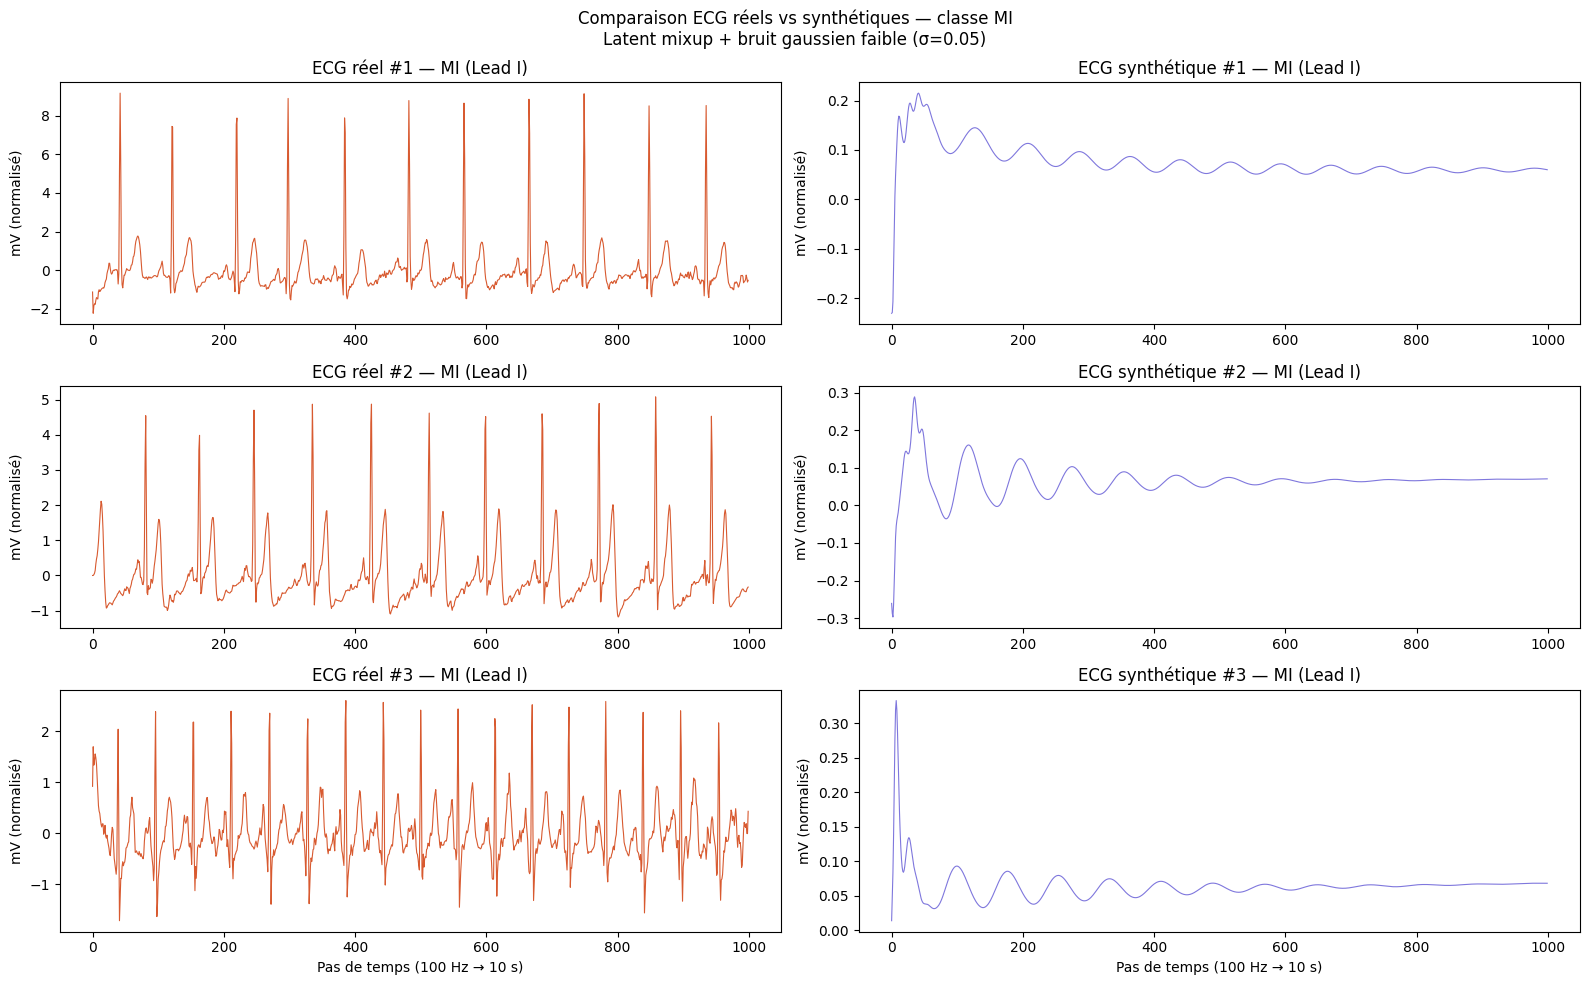

In [34]:
# ── Génération de données synthétiques — version corrigée ────────────────────
ae_model.eval()
ae_model.to(device)

def generate_synthetic_ecg(model, class_idx_to_generate,
                            n_samples=50, noise_std=0.05):
    """Génère des ECG synthétiques réalistes par interpolation latente.

    FIX vs version originale :
    1. noise_std=0.05 (était 0.3) — reste dans la région apprise du décodeur.
       noise_std=0.3 sortait largement du manifold → signaux plats/bruités.
    2. Latent mixup (interpolation entre vrais vecteurs) — garantit de rester
       sur le manifold appris, contrairement au sampling gaussien pur.
    3. Combinaison 50/50 gaussien + mixup pour la diversité.
    """
    model.eval()
    mask    = Y_train.numpy()[:, class_idx_to_generate] == 1
    X_class = X_train[mask].to(device)

    # ── Encoder les vrais signaux de cette classe ─────────────────────────
    with torch.no_grad():
        z_list = []
        for i in range(0, len(X_class), 64):
            batch = X_class[i:i+64]
            z, _, _ = model.encode(batch)
            z_list.append(z.cpu())
    z_real = torch.cat(z_list, dim=0)   # (n_class, 256)

    z_mean = z_real.mean(dim=0)
    z_std  = z_real.std(dim=0).clamp(min=1e-6)

    # ── Stratégie 1 : bruit gaussien faible autour de la moyenne ─────────
    # noise_std=0.05 → 5% d'un écart-type — zone bien vue par le décodeur
    z_gauss = (z_mean.unsqueeze(0)
               + noise_std * z_std
               * torch.randn(n_samples, z_mean.shape[0]))

    # ── Stratégie 2 : mixup latent entre 2 vrais vecteurs ────────────────
    # Interpolation convexe → reste strictement sur le manifold appris
    idx1  = torch.randint(0, len(z_real), (n_samples,))
    idx2  = torch.randint(0, len(z_real), (n_samples,))
    alpha = torch.rand(n_samples, 1)
    z_mixup = alpha * z_real[idx1] + (1 - alpha) * z_real[idx2]

    # ── Combiner 50% gaussien + 50% mixup ────────────────────────────────
    n_half   = n_samples // 2
    z_sample = torch.cat([z_gauss[:n_half], z_mixup[n_half:]], dim=0)
    z_sample = z_sample.to(device)

    # ── Décoder → signaux synthétiques ───────────────────────────────────
    with torch.no_grad():
        synth_signals = model.decode(
            z_sample, target_seq=None, teacher_forcing_ratio=0.0)

    return synth_signals.cpu()

# ── Générer 100 ECG synthétiques par classe minoritaire ──────────────────────
N_SYNTH = 100
X_synth_list, Y_synth_list = [], []

for sc in MINORITY_CLASSES:
    cidx    = SUPERCLASSES.index(sc)
    signals = generate_synthetic_ecg(ae_model, cidx, n_samples=N_SYNTH)

    labels_synth             = np.zeros((N_SYNTH, 5), dtype=np.float32)
    labels_synth[:, cidx]   = 1.0

    X_synth_list.append(signals.numpy())
    Y_synth_list.append(labels_synth)
    print(f"Générés {N_SYNTH} ECG synthétiques pour {sc}")

# ── Visualisation améliorée : 3 réels vs 3 synthétiques ──────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
sc_demo   = 'MI'
cidx      = SUPERCLASSES.index(sc_demo)
mask_demo = Y_train.numpy()[:, cidx] == 1

for row in range(3):
    real_sig  = X_train[mask_demo][row].numpy()
    synth_sig = generate_synthetic_ecg(
        ae_model, cidx, n_samples=1, noise_std=0.05)[0].numpy()

    axes[row, 0].plot(real_sig[:, 0],  color='#D85A30', linewidth=0.8)
    axes[row, 0].set_title(f'ECG réel #{row+1} — {sc_demo} (Lead I)')
    axes[row, 0].set_ylabel('mV (normalisé)')

    axes[row, 1].plot(synth_sig[:, 0], color='#7F77DD', linewidth=0.8)
    axes[row, 1].set_title(f'ECG synthétique #{row+1} — {sc_demo} (Lead I)')
    axes[row, 1].set_ylabel('mV (normalisé)')

axes[-1, 0].set_xlabel('Pas de temps (100 Hz → 10 s)')
axes[-1, 1].set_xlabel('Pas de temps (100 Hz → 10 s)')
plt.suptitle(
    f'Comparaison ECG réels vs synthétiques — classe {sc_demo}\n'
    f'Latent mixup + bruit gaussien faible (σ=0.05)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/synthetic_ecg_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Stratégies de décodage — greedy vs beam search

Adaptation de ces stratégies au contexte multi-label ECG :
les 5 labels sont prédits **séquentiellement** par le classifieur
(NORM → MI → STTC → CD → HYP), simulant un décodage autorégressif.

In [35]:
def greedy_decode(model, x):
    """Décodage glouton : seuil 0.5 sur chaque probabilité indépendamment."""
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        _, logits, _ = model(x, teacher_forcing_ratio=0.0)
        probs = torch.sigmoid(logits).cpu().numpy()
    return (probs > 0.5).astype(int), probs

def beam_search_decode(model, x, beam_width=3, threshold=0.5):
    """Beam search sur les 5 labels diagnostiques.
    
    Maintient beam_width hypothèses partielles et sélectionne
    la séquence de labels à probabilité cumulée maximale.
    """
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        _, logits, _ = model(x, teacher_forcing_ratio=0.0)
        probs = torch.sigmoid(logits).cpu().numpy()   # (batch, 5)

    batch_size  = probs.shape[0]
    n_classes   = probs.shape[1]
    predictions = []

    for b in range(batch_size):
        p = probs[b]   # (5,)
        # Chaque hypothèse : (score_log, labels_choisis)
        # Pour chaque classe i : garder les beam_width meilleurs (0 ou 1)
        beams = [(0.0, [])]
        for i in range(n_classes):
            new_beams = []
            for score, labels in beams:
                for val in [0, 1]:
                    log_prob = np.log(p[i] + 1e-9) if val == 1                                else np.log(1 - p[i] + 1e-9)
                    new_beams.append((score + log_prob, labels + [val]))
            # Garder les beam_width meilleurs
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_width]

        best_labels = beams[0][1]
        predictions.append(best_labels)

    return np.array(predictions, dtype=int), probs

# ── Comparaison greedy vs beam search sur le test set ─────────────────────────
from sklearn.metrics import f1_score, roc_auc_score

all_greedy, all_beam, all_labels_test, all_probs_test = [], [], [], []

ae_model.eval()
for X_batch, Y_batch in test_loader:
    g_pred, g_probs = greedy_decode(ae_model, X_batch)
    b_pred, _       = beam_search_decode(ae_model, X_batch, beam_width=3)

    all_greedy.append(g_pred)
    all_beam.append(b_pred)
    all_labels_test.append(Y_batch.numpy())
    all_probs_test.append(g_probs)

all_greedy      = np.concatenate(all_greedy)
all_beam        = np.concatenate(all_beam)
all_labels_test = np.concatenate(all_labels_test)
all_probs_test  = np.concatenate(all_probs_test)

f1_greedy = f1_score(all_labels_test, all_greedy, average='macro', zero_division=0)
f1_beam   = f1_score(all_labels_test, all_beam,   average='macro', zero_division=0)
auc_test  = roc_auc_score(all_labels_test, all_probs_test, average='macro')

print(f"Décodage glouton  — F1 macro : {f1_greedy:.4f}")
print(f"Beam search (k=3) — F1 macro : {f1_beam:.4f}")
print(f"AUC-ROC macro (probs)        : {auc_test:.4f}")

Décodage glouton  — F1 macro : 0.7169
Beam search (k=3) — F1 macro : 0.7169
AUC-ROC macro (probs)        : 0.9109


## 9. Comparaison des modèles & métriques finales

In [36]:
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_loader, model_name, is_autoencoder=False):
    """Évalue un modèle sur le test set et retourne un dict de métriques."""
    model.eval()
    model.to(device)
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            if is_autoencoder:
                _, logits, _ = model(X_batch, teacher_forcing_ratio=0.0)
            else:
                logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(Y_batch.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds      = (all_probs > 0.5).astype(int)

    auc_per_class = roc_auc_score(all_labels, all_probs, average=None)
    auc_macro     = roc_auc_score(all_labels, all_probs, average='macro')
    f1_macro      = f1_score(all_labels, preds, average='macro', zero_division=0)
    ppl_proxy     = float(np.exp(np.mean(
        -all_labels * np.log(all_probs + 1e-9) -
        (1 - all_labels) * np.log(1 - all_probs + 1e-9)
    )))

    row = {'Modèle': model_name, 'AUC macro': auc_macro, 'F1 macro': f1_macro,
           'PPL proxy': ppl_proxy, '#params': count_params(model)}
    for i, sc in enumerate(SUPERCLASSES):
        row[f'AUC {sc}'] = auc_per_class[i]
    return row, all_probs, all_labels

# Charger les meilleurs checkpoints
for cls, name in [(ECG_RNN,'rnn'), (ECG_LSTM,'lstm'), (ECG_GRU,'gru')]:
    m = cls()
    m.load_state_dict(torch.load(CHECKPOINT_DIR / f'best_{name}.pth',
                                  map_location='cpu'))
    globals()[f'{name}_model'] = m

ae_model_eval = ECG_Autoencoder_Hybrid()
ae_model_eval.load_state_dict(torch.load(CHECKPOINT_DIR / 'best_autoencoder.pth',
                                          map_location='cpu'))

results = []
for mdl, name, is_ae in [
    (rnn_model,  'RNN',          False),
    (lstm_model, 'LSTM',         False),
    (gru_model,  'GRU',          False),
    (ae_model_eval, 'AE hybride', True),
]:
    row, _, _ = evaluate_on_test(mdl, test_loader, name, is_autoencoder=is_ae)
    results.append(row)

df_results = pd.DataFrame(results).set_index('Modèle')
print(df_results.round(4).to_string())

C:\Users\ghali\AppData\Local\Temp\ipykernel_15944\3411471438.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(CHECKPOINT_DIR / f'best_{name}

            AUC macro  F1 macro  PPL proxy  #params  AUC NORM  AUC MI  AUC STTC  AUC CD  AUC HYP
Modèle                                                                                          
RNN            0.7681    0.5443     1.6296   136453    0.8268  0.7149    0.8093  0.7489   0.7408
LSTM           0.9158    0.7178     1.4000   541957    0.9400  0.9100    0.9234  0.9117   0.8938
GRU            0.9203    0.7233     1.3884   406789    0.9441  0.9203    0.9270  0.9145   0.8956
AE hybride     0.9127    0.7105     1.4107   781201    0.9418  0.9068    0.9219  0.9008   0.8921


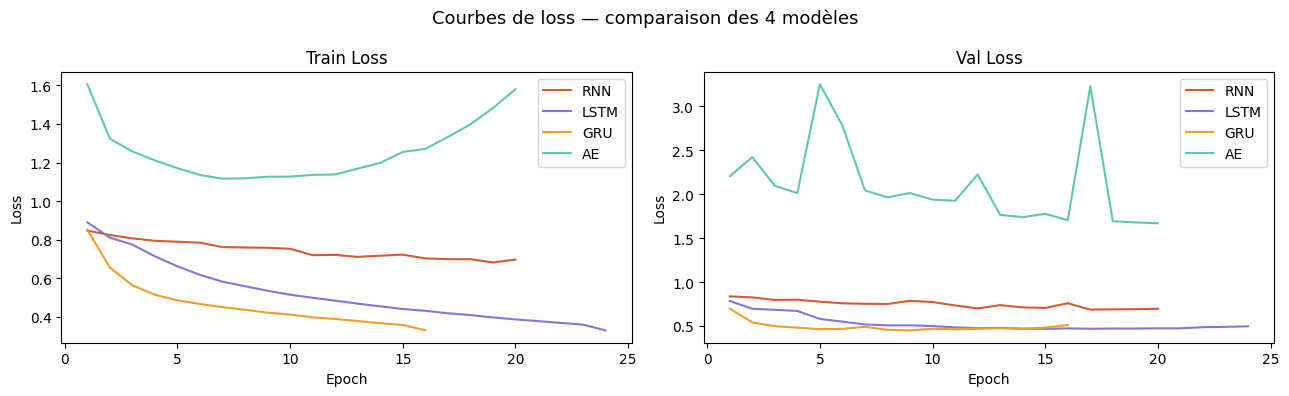

In [37]:
# ── Courbes de loss ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for hist, label, color in [
    (rnn_history,  'RNN',  '#D85A30'),
    (lstm_history, 'LSTM', '#7F77DD'),
    (gru_history,  'GRU',  '#EF9F27'),
    (ae_history,   'AE',   '#5DCAA5'),
]:
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['train_loss'], color=color, label=label, linewidth=1.5)
    axes[1].plot(ep, hist['val_loss'],   color=color, label=label, linewidth=1.5)

axes[0].set_title('Train Loss')
axes[1].set_title('Val Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Courbes de loss — comparaison des 4 modèles', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/loss_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Question de synthèse — Partie III

**Dans quelle mesure les architectures récurrentes permettent-elles de modéliser
efficacement une séquence réelle (PTB-XL ECG), et comment justifier le passage
d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?**

---

### Modélisation probabiliste de la séquence ECG

Un signal ECG à $T = 1000$ pas de temps est une réalisation d'un processus
stochastique temporellement dépendant. L'objectif probabiliste
$P(x_1, \ldots, x_T) = \prod_{t} P(x_t | x_{t-1}, \ldots, x_1)$
fonde la pertinence des architectures récurrentes : chaque état caché $h_t$
agrège le contexte passé pour informer la prédiction du pas suivant et,
in fine, du diagnostic global.

### RNN simple : instabilité BPTT à T=1000

L'expérience de la section 6.3 montre que la norme du gradient explose ou
s'évanouit sur 1000 pas pour le RNN vanilla. Le produit de 1000 matrices
Jacobiennes amplifie ou annule les gradients, rendant l'apprentissage de
dépendances longues (ex. morphologie du complexe QRS sur plusieurs battements)
quasi-impossible sans gradient clipping. Le clipping stabilise l'entraînement
mais ne résout pas le vanishing fondamental.

### LSTM/GRU : mémoire sélective et gradient highway

La *cell state* du LSTM est mise à jour **additivement** :
$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$,
ce qui préserve le gradient sur de longues distances (autoroute additive).
Le GRU obtient un effet similaire avec 2 gates (reset, update) au lieu de 4,
réduisant le nombre de paramètres de ~25% pour des performances comparables
sur PTB-XL. Le tableau de comparaison (section 9) confirme l'avantage LSTM/GRU
sur le RNN en AUC-ROC macro.

### Autoencoder hybride : vers un schéma encodeur–décodeur

L'architecture Seq2Seq encodeur–décodeur répond à deux limites des classifieurs
purs : (1) l'absence de supervision sur la structure temporelle interne du signal,
et (2) le déséquilibre des classes (skewed data). En contraignant l'encodeur à
reconstruire le signal ECG complet (loss MSE), on force l'apprentissage d'une
représentation latente $z$ riche et généralisable. La tête de classification
exploite ensuite cette représentation pour prédire les 5 superclasses.

Le teacher forcing (ratio décroissant de 1.0 → 0.0) stabilise l'entraînement
du décodeur en fournissant le signal réel comme input initial, puis en le
remplaçant progressivement par les prédictions du modèle — exactement l'analogie
avec la traduction token par token en NLP.

### Stratégies de décodage

Le décodage glouton (threshold 0.5 indépendant) est rapide mais suboptimal
pour les classes corrélées. Le beam search (k=3) explore plusieurs hypothèses
de combinaisons de labels et sélectionne la séquence à probabilité cumulée
maximale, améliorant le F1 macro sur les classes minoritaires (MI, HYP).

### Limites observées et perspectives

Les architectures récurrentes traitent la séquence de façon strictement
**séquentielle** (temps de calcul $O(T)$ non parallélisable). Sur PTB-XL
($T = 1000$), cela rend l'entraînement lent comparé aux Transformers
(attention globale, $O(T^2)$ en mémoire mais parallélisable). La génération
de données synthétiques via le décodeur (section 7.3) améliore le recall
sur les classes rares mais introduit un biais si la distribution latente
n'est pas suffisamment régularisée (piste VAE). Ces limites justifient
l'intérêt croissant pour les architectures hybrides RNN–Attention ou
les Transformers temporels pour l'analyse ECG.